In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.optimize import curve_fit
import os



<Figure size 640x480 with 0 Axes>

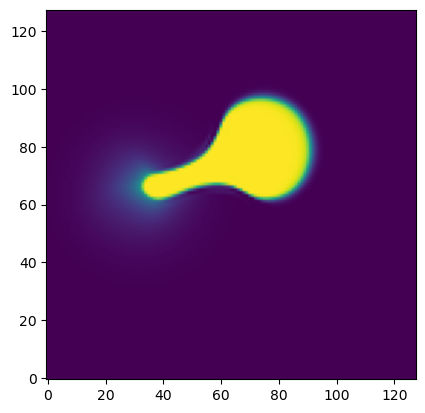

<Figure size 640x480 with 0 Axes>

In [4]:
prof = lambda x, A, alpha, x0, x1, b: A * (np.tanh(alpha * (x - x0)) + np.tanh(-alpha * (x - x1))) + b


dir = 'outputs\pol_sweep\sig_5_rbm_0.2\sim_data_20260424_103655/data.h5'
with h5py.File(dir, 'r') as f:
    psi_hist = f['solution/psi_hist'][:]
    # Gamma = f.attrs['parameters/lam_psi'][()]
    # R = f.attrs['parameters/rbm'][()]
    # D_psi = f.attrs['parameters/D_psi'][]


nt, nx, ny = np.shape(psi_hist)
lim = nx // 2


t = -1
plt.imshow(psi_hist[t], origin='lower', vmin=-1, vmax=1)
plt.figure()

# Differentiation

In [23]:
import os
import h5py
import numpy as np
from scipy.optimize import curve_fit

# prof = lambda x, A, alpha, x0, x1, b: A * (np.tanh(alpha * (x - x0)) + np.tanh(-alpha * (x - x1))) + b
# prof = lambda x, A, alpha, xt, b: A * np.tanh(alpha * (x - xt)) + b



base_dir = "outputs/pol_sweep"
results = []

for sim_dir in sorted(os.listdir(base_dir)):
    base_dir2 = os.path.join(base_dir, sim_dir)
    for sim_dir2 in sorted(os.listdir(base_dir2)):
        full_dir = os.path.join(base_dir2, sim_dir2)
        if not os.path.isdir(full_dir):
            continue

        # Find data.h5 (or all *.h5) in that folder
        possible_h5 = [f for f in os.listdir(full_dir) if f.endswith(".h5")]
        if not possible_h5:
            continue

        h5_path = os.path.join(full_dir, possible_h5[0])
        with h5py.File(h5_path, "r") as f:
            if "solution/psi_hist" not in f:
                continue
            psi_hist = f["solution/psi_hist"][:]
            qx_hist = f["solution/qx_hist"][:]
            qy_hist = f["solution/qy_hist"][:]
            x = f[ "grid/x"][:]
            y = f[ "grid/y"][:]

            if psi_hist.ndim not in (2,3):
                continue

            # final state
            psi_final = psi_hist[-1]
            qx_final = qx_hist[-1]
            qy_final = qy_hist[-1]
            nt, nx, ny = psi_hist.shape
            q_mag_final = np.sqrt(qx_final**2 + qy_final**2)
            # Use threshold instead of isclose (more lenient for floating point)
            has_ones = np.any(psi_final > 0.90)
            max_psi = np.max(psi_final)
            frac_ones = np.sum(0.5 * (np.clip(psi_final, -1, 1) + 1)) / (nx * ny)  # Fraction of grid with psi > 0.90
            frac_q = np.sum(q_mag_final) / (nx * ny)  # Fraction of grid with q_mag > 0.1

            X, Y = np.meshgrid(x, y, indexing='ij')
            mask = psi_final > 0.0   # or 0.5, depending on your model

            if np.any(mask):
                xcm = np.sum(X[mask]) / np.sum(mask)
                ycm = np.sum(Y[mask]) / np.sum(mask)
            else:
                xcm = np.nan
                ycm = np.nan




            results.append((sim_dir, sim_dir2, has_ones, max_psi, frac_ones, frac_q, xcm, ycm))

            # plt.figure()
            # plt.imshow(psi_final[:], label='psi', vmin=-1, vmax=1)
            # plt.title(sim_dir)

# print summary
print(f"{'Group':<30} {'Simulation':<40} {'psi>0.90':<10}   {'frac_ones':<10}    {'frac_q':<10}    {'xcm':<10}    {'ycm':<10}")
print("-" * 135)
for group, sim_dir, has_ones, max_psi, frac_ones, frac_q, xcm, ycm in results:
    print(f"{group:<30} {sim_dir:<40}   {str(has_ones):<10}   {frac_ones:<10.4e}   {frac_q:<10.4e}   {xcm:<10.4e}   {ycm:<10.4e}")

total = len(results)
with_ones = sum(1 for r in results if r[2])
print(f"\nScanned {total} sims, {with_ones} have psi>0.90 at final state.")


Group                          Simulation                               psi>0.90     frac_ones     frac_q        xcm           ycm       
---------------------------------------------------------------------------------------------------------------------------------------
sig_5_rbm_0.1                  sim_data_20260424_110119                   False        1.7186e-15   4.3285e-03   nan          nan       
sig_5_rbm_0.1                  sim_data_20260424_110237                   False        1.5372e-15   4.3294e-03   nan          nan       
sig_5_rbm_0.1                  sim_data_20260424_110358                   False        1.5431e-15   4.3231e-03   nan          nan       
sig_5_rbm_0.1                  sim_data_20260424_110515                   False        1.4632e-15   4.0596e-03   nan          nan       
sig_5_rbm_0.1                  sim_data_20260424_110632                   False        1.4744e-15   3.5263e-03   nan          nan       
sig_5_rbm_0.2                  sim_data_2

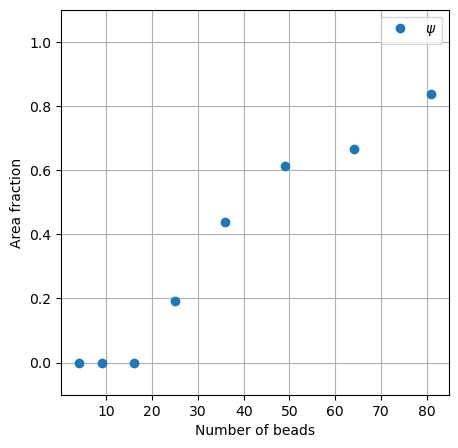

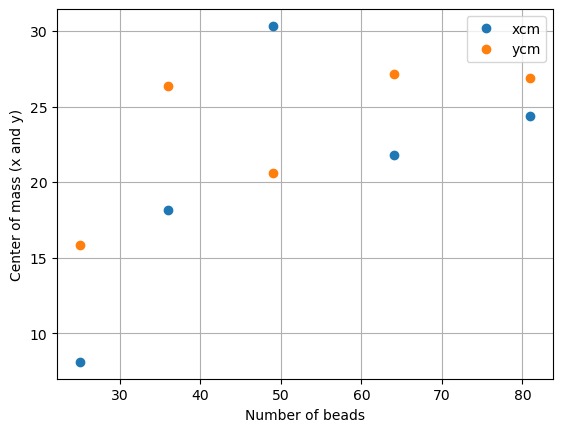

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Plot phase diagram with nucleation detection points overlaid
fig, ax = plt.subplots(figsize=(5, 5))



# Extract differentiation fraction from results
frac_dict = {}  # Dictionary to accumulate fractions by number of beads
frac_q_dict = {}  # Dictionary to accumulate q fractions by number of beads
xcm_dict = {}
ycm_dict = {}

for group, sim_dir, has_ones, max_psi, frac_ones, frac_q, xcm, ycm in results:
    # Parse group name: 'nb_X'
    parts = group.split('_')
    try:
        nbd_idx = parts.index('nb')
        sig_val = float(parts[nbd_idx + 1])
        rbm_idx = parts.index('rbm')
        rbm_val = float(parts[rbm_idx + 1])
        
        # Accumulate fractions for each nbd value
        if nbd_val not in frac_q_dict:
            frac_q_dict[nbd_val] = []
            frac_dict[nbd_val] = []
            xcm_dict[nbd_val] = []
            ycm_dict[nbd_val] = []

        frac_q_dict[nbd_val].append(frac_q)
        frac_dict[nbd_val].append(frac_ones)
        xcm_dict[nbd_val].append(xcm)
        ycm_dict[nbd_val].append(ycm)
    except (ValueError, IndexError):
        continue

# Calculate averages
nbd = sorted(frac_q_dict.keys())
frac_q = [np.mean(frac_q_dict[n]) for n in nbd]
frac = [np.mean(frac_dict[n]) for n in nbd]
xcm = [np.mean(xcm_dict[n]) for n in nbd]
ycm = [np.mean(ycm_dict[n]) for n in nbd]


# ax.plot(nbd, frac_q, 'o', label=r'$q$')
ax.set_xlabel('Number of beads')

ax.plot(nbd, frac, 'o', label=r'$\psi$')
ax.set_xlabel('Number of beads')
ax.set_ylabel(r'Area fraction')
ax.set_ylim(-0.1, 1.1)
plt.legend()
plt.grid()


ax = plt.figure().add_subplot(111)
ax.plot(nbd, xcm, 'o', label='xcm')
ax.plot(nbd, ycm, 'o', label='ycm')
ax.set_xlabel('Number of beads')
ax.set_ylabel('Center of mass (x and y)')
plt.legend()
plt.grid()


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'outputs/pol_spread\\sig_5_rbm_0.1\\sim_data_20260424_110119'

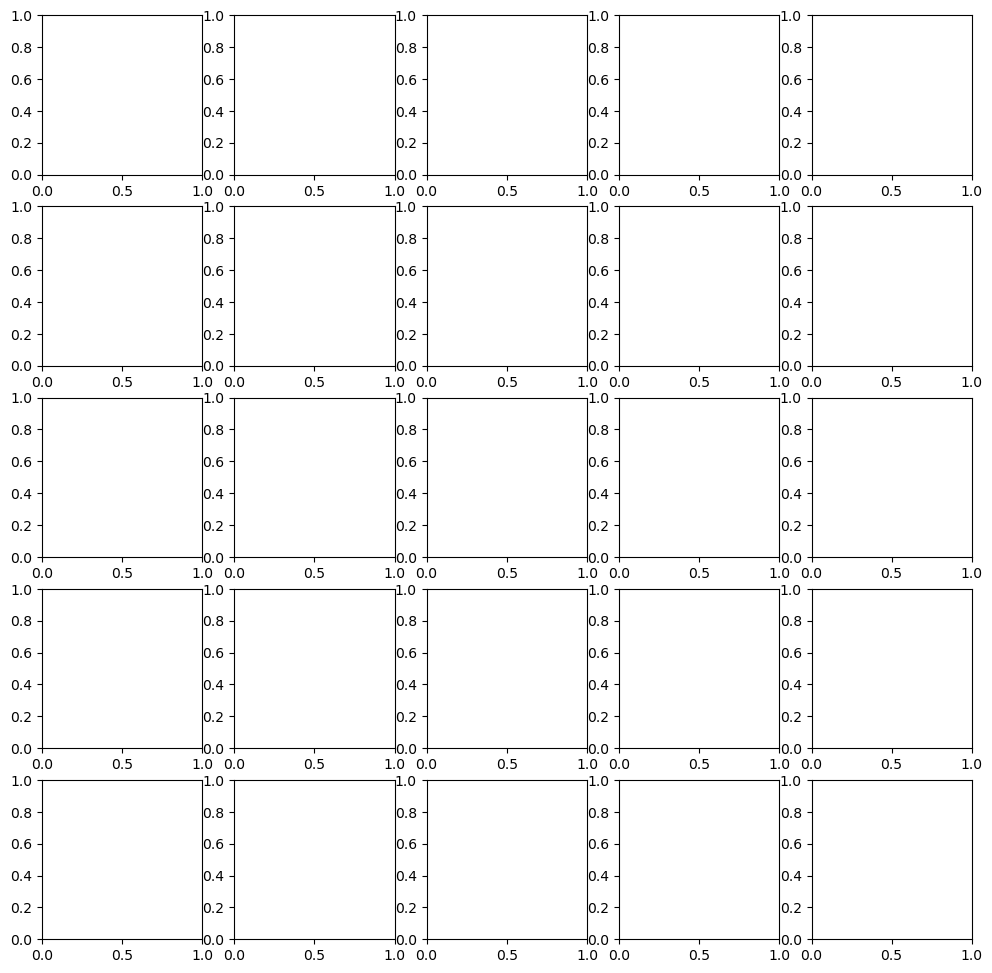

In [24]:

# Plot final psi field with center of mass position
base_dir = "outputs/pol_spread"
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

plot_idx = 0
for sim_idx, (group, sim_dir, has_ones, max_psi, frac_ones, frac_q, xcm_val, ycm_val) in enumerate(results):
    if plot_idx >= len(axes):
        break
    
    base_dir2 = os.path.join(base_dir, group)
    full_dir = os.path.join(base_dir2, sim_dir)
    
    possible_h5 = [f for f in os.listdir(full_dir) if f.endswith(".h5")]
    if not possible_h5:
        continue
    
    h5_path = os.path.join(full_dir, possible_h5[0])
    with h5py.File(h5_path, "r") as f:
        psi_hist = f["solution/psi_hist"][:]
        x = f["grid/x"][:]
        y = f["grid/y"][:]
        bead_positions = f['grid/bead_positions'][:]
        
        psi_final = psi_hist[-1]
        
        ax = axes[plot_idx]
        im = ax.imshow(psi_final, origin='lower', vmin=-1, vmax=1, cmap='RdBu_r', extent=[x[0], x[-1], y[0], y[-1]])
        ax.scatter(bead_positions[:, 0], bead_positions[:, 1], c='w', marker='o', alpha=0.5, edgecolors='w', s=5)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Plot center of mass if it exists
        if has_ones and not np.isnan(xcm_val) and not np.isnan(ycm_val):
            ax.plot(xcm_val, ycm_val, 'ko', markersize=8, markerfacecolor='none', markeredgewidth=2)
        
        ax.set_title(f'{group}\n{sim_dir}', fontsize=9)
        ax.set_xlabel('x', fontsize=8)
        ax.set_ylabel('y', fontsize=8)
        ax.tick_params(labelsize=7)
        
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('final_psi_fields_with_beads.png', dpi=300)

### Plot final states

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os
import h5py

base_dir = "outputs/pol_sweep"
out_dir = os.path.join(base_dir, "final_states")
os.makedirs(out_dir, exist_ok=True)

results = []

for sim_dir in sorted(os.listdir(base_dir)):
    base_dir2 = os.path.join(base_dir, sim_dir)
    for sim_dir2 in sorted(os.listdir(base_dir2)):
        full_dir = os.path.join(base_dir2, sim_dir2)
        if not os.path.isdir(full_dir):
            continue

        # Find data.h5 (or all *.h5) in that folder
        possible_h5 = [f for f in os.listdir(full_dir) if f.endswith(".h5")]
        if not possible_h5:
            continue

        h5_path = os.path.join(full_dir, possible_h5[0])
        with h5py.File(h5_path, "r") as f:
            if "solution/psi_hist" not in f:
                continue
            psi_hist = f["solution/psi_hist"][:]
            qx_hist = f["solution/qx_hist"][:]
            qy_hist = f["solution/qy_hist"][:]
            x = f[ "grid/x"][:]
            y = f[ "grid/y"][:]

            if psi_hist.ndim not in (2,3):
                continue

            # final state
            psi_final = psi_hist[-1]
            
            fig, ax = plt.subplots(figsize=(5, 5))
            im = ax.imshow(psi_final, origin='lower', vmin=-1, vmax=1, cmap='RdBu_r', extent=[x[0], x[-1], y[0], y[-1]])
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_title(f'{sim_dir}', fontsize=9)
            plt.savefig(os.path.join(out_dir, f'{sim_dir2}.png'), dpi=300, bbox_inches='tight')
            plt.close()

